In [51]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import matplotlib.cm as cm
import datetime 
import time
from scipy.fft import fft, ifft, fftshift
from scipy.fftpack import fftfreq
from EOF import EOF
import gc
from multiprocessing import Pool
from Zonal_Calculation import Zonal_Calculation

In [52]:
# Function to calculate EOF and PC
def Cal_EOF_PC(input_data):
    from EOF import EOF
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[2]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="2D")
    eof_instance.get()

    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]
    PC1_std = PC1.std()
    

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    return EOF1_norm.reshape(20,32), PC1_norm, EOF2_norm.reshape(20,32), PC2_norm, eof_instance.explained[:10]

# Calculate EP flux statistical test for npj reject

In [3]:
"""
Original EP flux step:
Calcuate PC1 -> PC1_positive = PC1 > PC1.mean() + PC1.std()
             -> PC1_negative = PC1 < PC1.mean() - PC1.std()

lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days

take PC1_positvie to calculate each lag EP flux
for lag in list(lags_5_20) + list(lags_30_60):
    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_positive,), "positive")
    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_negative,), "negative")
        

# Step 2: load calculated EP flux, and mean them
for PR in PR_values:
    print(f"Calculating mean EP flux for PR = {PR}")
    
    F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20")
    F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60")
    
    # Calculate the difference between the two means
    F_j_mean_diff = F_j_mean_5_20 - F_j_mean_30_60
    F_k_mean_diff = F_k_mean_5_20 - F_k_mean_30_60
    
    # np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_{PR}.npy"), F_j_mean_diff)
    # np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_{PR}.npy"), F_k_mean_diff)
    print(f"Saved EP flux difference for PR = {PR}")

#############################################################################################################
Statistical test for EP flux:
use print(random.choice(100,10, replace=False))  # [20  0 89 42 47 57 76 71 14  4]

Calcuate PC1 -> PC1_positive_random = print(random.choice(78000, PC1_positive.size))
             -> PC1_negative_random = print(random.choice(78000, PC1_negative.size))
             
lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days

take PC1_positvie to calculate each lag EP flux
for lag in list(lags_5_20) + list(lags_30_60):
    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_positive,), "positive")
    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_negative,), "negative")
        

# Step 2: load calculated EP flux, and mean them
for PR in PR_values:
    print(f"Calculating mean EP flux for PR = {PR}")
    
    F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20")
    F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60")
    
    # Calculate the difference between the two means
    F_j_mean_diff = F_j_mean_5_20 - F_j_mean_30_60
    F_k_mean_diff = F_k_mean_5_20 - F_k_mean_30_60
    
    # np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_{PR}.npy"), F_j_mean_diff)
    # np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_{PR}.npy"), F_k_mean_diff)
    print(f"Saved EP flux difference for PR = {PR}")

"""

'\nOriginal EP flux step:\nCalcuate PC1 -> PC1_positive = PC1 > PC1.mean() + PC1.std()\n             -> PC1_negative = PC1 < PC1.mean() - PC1.std()\n\nlags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days \nlags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days\n\ntake PC1_positvie to calculate each lag EP flux\nfor lag in list(lags_5_20) + list(lags_30_60):\n    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_positive,), "positive")\n    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_negative,), "negative")\n        \n\n# Step 2: load calculated EP flux, and mean them\nfor PR in PR_values:\n    print(f"Calculating mean EP flux for PR = {PR}")\n    \n    F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20")\n    F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60")\n    \n    # Calculate the difference between the two means\n    F_j_mean_diff = F_

In [ ]:
"""
打亂time index -> 檢測特定的time index 選的EP flux 有沒有顯著大於氣候背景場


實驗跟實驗相減 L = 0.1~0.5 - Dry
-> 想看不同實驗跟乾的EP flux有沒有明顯不一樣

Original: L = 0.1 - Dry -> Fig.1
    if shape( 1000, 500)
          
H_0: L = 0.1 EP flux 有沒有顯著大於or小於Dry的EP flux

(L=0.1 normal distribution的mean) - (L=Dry normal distribution的mean) 有沒有顯著不同
t-test equation:
...
做500次：
（在[L = 0.1 or L = Dry]去隨機選L=0.1.shape的數量的EP flux） - （在[L = 0.1 or L = Dry]去L=Dry.shape 數量EP flux）
    [兩個pool先選一個]              1000                             看前面選到哪個就是那個   500



"""

In [ ]:
"""
做500次：
（在[L = 0.1 or L = Dry]去隨機選L=0.1.shape的數量的EP flux） - （在[L = 0.1 or L = Dry]去L=Dry.shape 數量EP flux）
    [兩個pool先選一個]              1000                             看前面選到哪個就是那個   500

-> 在L=0.1 or Dry兩個pools中隨機選一個 然後選出L=0.1.shape的數量的EP flux -(按照前面選的pool 如果前面選L=0.1後面也選L=0.1; 如果前面選L=Dry 後面也跟著選Dry 然後選出跟L=0.1shape的數量)

我的疑問是 為什麼要從兩個pool隨機選一個 然後後面那個pool要照做
為什麼不是：
（在[L = 0.1 ]去隨機選L=0.1.shape的數量的EP flux） - （在[L = Dry]去L=Dry.shape 數量EP flux）？？？


🔍 你提的兩種方法其實是兩種不同的統計假設檢定方式：

✅ 方法 A（你現在提問的直覺做法）：
（從 L=0.1 中抽樣 1000） -（從 Dry 中抽樣 500）
然後重複 500 次，建立一個差值分布，來估計兩組的平均差異是否顯著。
➕ 優點：

很直觀、直接對兩組樣本進行重抽樣。
適合在你相信「L=0.1 與 Dry 是不同的實驗條件」，你想保留組別差異。
➖ 缺點：

這樣的重抽樣是基於已經有組別標籤的情況（≠ permutation test 的邏輯）。
所以它是「bootstrap test」，不是 permutation test。
這樣得到的分布，是每組內部的 sampling variability，而不是 under H₀ 的 distribution。

✅ 方法 B（原本你寫的那種做法）：
從 [L=0.1 + Dry 合併的 pool] 中選一組（隨機選 L=0.1 或 Dry）→ 然後兩次都從同一組裡抽出樣本（1000 vs 500）做差。重複 500 次。
➕ 優點：

這其實是 permutation test 的一種特例：你假設 L=0.1 和 Dry 的 EP flux 是來自同一個分布，然後從「同一個 group」中抽兩組樣本。
這樣你建立的是 **null hypothesis 成立時（兩組沒差）**的期望分布。
最後你把「實際 L=0.1 和 Dry 的差」套進這個分布中，估計 p-value。
➖ 缺點：

它有點「反直覺」，因為你不是從兩組各自抽樣。
但統計上這是更嚴格（保守）的檢定方式，因為它假設組別是可互換的。


🔑 為什麼要這樣做？（方法 B 的統計邏輯）

因為你想檢定的是：

「L=0.1 的 EP flux 是否真的和 Dry 有差？」
那麼你就要建立一個「在 L=0.1 與 Dry 沒差別時，差值會長什麼樣子」的分布。

所以你從同一個組裡（假裝它們來自相同分布）抽兩組，再去觀察差異。
這就符合 H₀: 沒有差異（同分布） 的假設。

然後把你原本觀察到的μ_0.1 - μ_Dry 放進去，去看它有多極端（≒ p-value）。
🎯 小結：

         方法	                    檢定邏輯	                      適用情況
A：各自從 L=0.1 和 Dry 中抽樣  | 觀察組內 sampling variability|	當你相信兩組本來就不同
B：從同一個 pool 裡抽兩組	    | 模擬 H₀ 成立下的樣本差分布      |	要檢定「是否顯著不同」時使用
✅ 你如果想做「是否顯著不同」的統計檢定，就應該用方法 B，也就是你原本的寫法。


"""

# 🌊 EP Flux 顯著性檢定：L = 0.1 vs Dry 實驗

## 🎯 研究目標

檢驗在不同實驗條件（L=0.1 與 Dry）下，EP flux 是否存在顯著差異。

- **虛無假設 H₀**：L=0.1 與 Dry 的 EP flux 來自同一個母體分布（沒有顯著差異）。
- **對立假設 H₁**：L=0.1 與 Dry 的 EP flux 平均值存在顯著差異。

---

## 📊 t-test 方程式（參考用）

傳統的獨立樣本 t-test：

$$
t = \frac{\bar{x}_{L=0.1} - \bar{x}_{Dry}}{\sqrt{\frac{s_{0.1}^2}{n_{0.1}} + \frac{s_{Dry}^2}{n_{Dry}}}}
$$

- $$( \bar{x}, s^2 )$$：樣本平均值與變異數  
- $$( n_{0.1} = 1000 )$$，$$( n_{Dry} = 500 )$$

---

## 🔁 非參數隨機化檢定（Permutation Test）

考慮資料非完全常態、或希望建立在 H₀ 成立下的差值分布，我們採用 permutation test：

### 檢定流程：

1. **合併樣本池**：
    - 將 L=0.1 和 Dry 的 EP flux 合併成一個 pool。
2. **隨機選擇使用哪一個 pool（L=0.1 或 Dry）**：
    - 兩次抽樣都使用這個 pool。
3. **從該 pool 中抽樣兩組資料**：
    - 第一組抽出與 L=0.1 同樣的樣本數（1000）
    - 第二組抽出與 Dry 同樣的樣本數（500）
4. **計算兩組的平均差值**：
    $$
    \Delta^{(i)} = \bar{x}_1^{(i)} - \bar{x}_2^{(i)}
    $$
5. **重複 500 次**，建立在虛無假設成立下的差值分布。
6. **計算實際差值**：
    $$
    \Delta_{obs} = \bar{x}_{L=0.1} - \bar{x}_{Dry}
    $$
7. **估算 p-value**：
    $$
    p = \frac{\text{隨機試驗中 } |\Delta^{(i)}| \ge |\Delta_{obs}| \text{ 的次數}}{500}
    $$

---

## 🤔 為什麼不是直接從兩組各自抽樣？

雖然可以從 L=0.1 和 Dry 中各自抽樣（稱為 bootstrap test），但這樣只是估計抽樣誤差，**無法模擬 H₀ 成立時的差值分布**。

我們的目標是檢定兩組是否來自相同分布，因此應採用 permutation test，讓組別可交換（exchangeable），模擬 H₀ 成立時的隨機差值行為。

---

## 📈 視覺化檢定分布

下圖顯示 permutation test 的結果。灰色為在 H₀ 成立下，500 次重抽樣所產生的平均差值分布，紅線為實際觀測差值，藍色區域為較極端的差異（用以估計 p-value）。

![Permutation Test EP Flux Difference](permutation_test_ep_flux.png)



In [14]:
# """
# ep_flux_mean_dir_1_1: Fig.4-1 lags_5_20: np.linspace(5*4,20*4,1)
# ep_flux_mean_dir    : Fig.4-1 lags_5_20: np.linspace(15*4,20*4,1)
# ep_flux_mean_dir_1_2: Fig.4-2 dot
# ep_flux_mean_dir_1_3: Fig.4-2 dot after doing chunk

# """


# # Function to calculate EOF and PC
# def Cal_EOF_PC(input_data):
#     from EOF import EOF
    
#     # Perform latitude weighting
#     input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[2]))))

#     # Initialize an EOF instance with weighted input data
#     n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

#     eof_instance = EOF((input_data_weighted,), n_components=n_component, field="2D")
#     eof_instance.get()

#     # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
#     EOF1, EOF2 = eof_instance.EOF[:2]
#     PC1, PC2 = eof_instance.PC[:2]
#     PC1_std = PC1.std()
    
#     # Normalize PCs and EOFs
#     PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
#     EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
#     return EOF1_norm.reshape(20,32), PC1_norm, EOF2_norm.reshape(20,32), PC2_norm, eof_instance.explained[:10], PC1_std

# # Function to read data from HDF5
# def Read_var_simple(var, PR):
#     str_var = str(var)
#     common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
#     last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
#     with h5py.File(common_path + last_path, 'r') as file:
#         data = np.asarray(file[str_var][:])
#     return data

# # Function to load saved components
# def load_lagged_components(PR, lag, save_dir, suffix, num_sample):
#     F_j_lag = np.load(f"{save_dir}/F_j_lag_{lag}_PR_{PR}_{suffix}_{num_sample}_samplings.npy")
#     F_k_lag = np.load(f"{save_dir}/F_k_lag_{lag}_PR_{PR}_{suffix}_{num_sample}_samplings.npy")
#     return F_j_lag, F_k_lag

# # # Function to calculate and save lagged components for given time indices
# # def calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx, suffix, num_sample):
# #     # Read zonal mean variables
# #     theta_zonal_mean_all = Read_var_simple("theta", PR)
# #     dtheta_all           = Read_var_simple("dtheta", PR)
# #     dz_all               = Read_var_simple("dz", PR)
# #     v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
# #     EMF_all              = Read_var_simple("EMF", PR)

# #     # Calculate N squared
# #     dthetadz_all = dtheta_all / dz_all
# #     N_square_all = g / theta_zonal_mean_all * dthetadz_all

# #     # Calculate lagged indices
# #     # time_idx_lag = np.asarray(time_idx) + lag
# #     time_idx_lag = time_idx[0] + lag
    
# #     z_idx, y_idx = theta_zonal_mean_all.shape[1], theta_zonal_mean_all.shape[2]

# #     theta_zonal_mean_lag = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
# #     dtheta_lag           = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
# #     dz_lag               = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
# #     v_prime_b_prime_lag  = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
# #     EMF_lag              = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))

# #     F_j_lag_num_sampling = np.zeros((num_sample, z_idx, y_idx))
# #     F_k_lag_num_sampling = np.zeros((num_sample, z_idx, y_idx))
    
# #     for ens in range(num_sample):
# #         for i in range(len(time_idx[0])):
# #             theta_zonal_mean_lag[i] = theta_zonal_mean_all[int(time_idx_lag[i]), :, :] 
# #             dtheta_lag[i]           = dtheta_all[int(time_idx_lag[i]), :, :] 
# #             dz_lag[i]               = dz_all[int(time_idx_lag[i]), :, :]
# #             v_prime_b_prime_lag[i]  = v_prime_b_prime_all[int(time_idx_lag[i]), :, :] 
# #             EMF_lag[i]              = EMF_all[int(time_idx_lag[i]), :, :] 
    
# #         dthetadz_lag = dtheta_lag / dz_lag
# #         N_square_lag = g / theta_zonal_mean_lag * dthetadz_lag
    
# #         F_j_long_time_mean = EMF_all.mean(axis=0)
# #         F_k_long_time_mean = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_all / N_square_all).mean(axis=0) 
        
# #         F_j_lag[ens] = EMF_lag.mean(axis=0) - F_j_long_time_mean
# #         F_k_lag[ens] = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_lag / N_square_lag).mean(axis=0) - F_k_long_time_mean
    
# #         # Save the results
# #     os.makedirs(save_dir, exist_ok=True)
# #     np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_j_lag_num_sampling)
# #     np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_k_lag_num_sampling)
# #     print(f"Saved F_j and F_k for PR={PR}, lag={lag}, condition={suffix}")

# def calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx, suffix, num_sample):
#     # Read zonal mean variables
#     theta_zonal_mean_all = Read_var_simple("theta", PR)
#     dtheta_all           = Read_var_simple("dtheta", PR)
#     dz_all               = Read_var_simple("dz", PR)
#     vpbp_all             = Read_var_simple("v_prime_b_prime", PR)
#     EMF_all              = Read_var_simple("EMF", PR)

#     # Precompute long-time means and N²
#     dthetadz_all = dtheta_all / dz_all
#     N2_all = g / theta_zonal_mean_all * dthetadz_all

#     F_j_mean = EMF_all.mean(axis=0)
#     F_k_mean = (f0[np.newaxis, np.newaxis, :] * vpbp_all / N2_all).mean(axis=0)

#     sel_time_size = time_idx.shape[1] # (500, time_positive_inddex.shape)
    
#     # Get lagged time indices
#     time_idx_lagged = (time_idx + lag).astype(int)
#     print(time_idx_lagged.shape)
#     time_idx_lagged = np.clip(time_idx_lagged, 0, theta_zonal_mean_all.shape[0] - 1)
    
#     # Vectorized data extraction
#     theta_lag = theta_zonal_mean_all[time_idx_lagged]
#     dtheta_lag = dtheta_all[time_idx_lagged]
#     dz_lag = dz_all[time_idx_lagged]
#     vpbp_lag = vpbp_all[time_idx_lagged]
#     EMF_lag = EMF_all[time_idx_lagged]

#     # Reshape to (num_sample, num_times, z, y)
#     theta_lag = theta_lag.reshape((num_sample, *theta_lag.shape[1:]))
#     dtheta_lag = dtheta_lag.reshape((num_sample, *dtheta_lag.shape[1:]))
#     dz_lag = dz_lag.reshape((num_sample, *dz_lag.shape[1:]))
#     vpbp_lag = vpbp_lag.reshape((num_sample, *vpbp_lag.shape[1:]))
#     EMF_lag = EMF_lag.reshape((num_sample, *EMF_lag.shape[1:]))

#     # Compute lagged N²
#     N2_lag = g / theta_lag * (dtheta_lag / dz_lag)

#     # Mean over time dimension
#     EMF_lag_mean = EMF_lag.mean(axis=1)
#     F_j_lag = EMF_lag_mean - F_j_mean

#     F_k_lag_mean = (f0[np.newaxis, np.newaxis, :] * vpbp_lag / N2_lag).mean(axis=1)
#     F_k_lag = F_k_lag_mean - F_k_mean

#     # Save the result
#     os.makedirs(save_dir, exist_ok=True)
#     np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_j_lag)
#     np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_k_lag)
#     print(f"✅ Saved lagged components for PR={PR}, lag={lag}, condition={suffix}")




# # Constants
# f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90, 90, 64)))
# g = 9.81

# # PR values and lags to process
# PR_values  = range(0, 60, 10)
# lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
# lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days
# save_dir          = "EP_flux_statistical_test/EP_flux_results"       # Directory to save results
# pc1_save_dir      = "EP_flux_statistical_test/PC1_results"           # Directory to save PC1 results
# time_idx_save_dir = "EP_flux_statistical_test/time_idx_results"      # Directory to save time_idx results
# ep_flux_mean_dir  = "EP_flux_statistical_test/EP_flux_mean_results"  # Directory to save mean EP flux results

# # Storage for EOFs and PCs across different PR values
# EOF1_all_PRs = {}
# EOF2_all_PRs = {}
# PC1_all_PRs = {}
# PC2_all_PRs = {}
# explained_variance_PRs = {}
# time_idx_PRs = {}
# PC1_std_PRs = {}

# # Ensure the mean EP flux directory exists
# os.makedirs(ep_flux_mean_dir, exist_ok=True)

# # Function to calculate mean EP flux over specified lags
# def calculate_mean_flux(PR, lags, suffix, num_sample):
#     F_j_mean = np.zeros_like(np.load(f"{save_dir}/F_j_lag_{lags[0]}_PR_{PR}_positive_{num_sample}_samplings.npy"))
#     F_k_mean = np.zeros_like(np.load(f"{save_dir}/F_k_lag_{lags[0]}_PR_{PR}_positive_{num_sample}_samplings.npy"))
    
#     for lag in lags:
#         F_j_positive, F_k_positive = load_lagged_components(PR, lag, save_dir, "positive", num_sample)
#         F_j_negative, F_k_negative = load_lagged_components(PR, lag, save_dir, "negative", num_sample)
        
#         F_j_mean += (F_j_positive - F_j_negative) 
#         F_k_mean += (F_k_positive - F_k_negative) 
    
#     F_j_mean /= len(lags)
#     F_k_mean /= len(lags)
    
#     np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_{suffix}_PR_{PR}_{num_sample}_sampling.npy"), F_j_mean)
#     np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_{suffix}_PR_{PR}_{num_sample}_sampling.npy"), F_k_mean)

#     return F_j_mean, F_k_mean

# num_sample = 500
# # Step 1: Calculate and save lagged components for each PR and lag
# for PR in PR_values:
#     print(f"Processing PR = {PR}")
#     """
#     # Read the U data for the current PR
#     u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u_zonal_mean.h5"
#     with h5py.File(u_file, "r") as u_file0:
#         u_data = np.asarray(u_file0["u"][:,:])
    
#     # Calculate EOFs and PCs for the current PR
#     EOF1, PC1, EOF2, PC2, explained_variance, PC1_std = Cal_EOF_PC(u_data[:,:,32:])
    
#     # Normalize the sign of EOF1
#     if PR > 0:  # Assuming PR=0 is the baseline
#         sign_correction = np.sign(np.dot(EOF1_all_PRs[PR_values[0]].reshape(-1), EOF1.reshape(-1)))
#         EOF1 *= sign_correction
#         PC1 *= sign_correction
    
#     # Store the results
#     EOF1_all_PRs[PR] = EOF1
#     EOF2_all_PRs[PR] = EOF2
#     PC1_all_PRs[PR] = PC1
#     PC2_all_PRs[PR] = PC2
#     explained_variance_PRs[PR] = explained_variance
#     PC1_std_PRs[PR] = PC1_std
    
#     # Save PC1 and EOF1 to file for later inspection
#     os.makedirs(pc1_save_dir, exist_ok=True)
#     np.save(os.path.join(pc1_save_dir, f"PC1_PR_{PR}.npy"), PC1)
#     np.save(os.path.join(pc1_save_dir, f"EOF1_PR_{PR}.npy"), EOF1)
#     np.save(os.path.join(pc1_save_dir, f"PC1_std_PR_{PR}.npy"), PC1_std)
#     """
#     PC1_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PC1_results/PC1_PR_{PR}.npy"
    
#     PC1 = np.asarray(np.load(PC1_file))
#     # Calculate time_idx for PC1 > 1*std
#     time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
#     time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
    
#     # Adjust time_idx values if they exceed the limit
#     max_idx = int(78000 - 100*4)
#     time_idx_array_positive = time_idx_positive[time_idx_positive <= max_idx]
#     time_idx_array_negative = time_idx_negative[time_idx_negative <= max_idx]

#     time_idx_array_positive_stat = np.zeros((500, time_idx_array_positive.shape[0]))
#     time_idx_array_negative_stat = np.zeros((500, time_idx_array_negative.shape[0]))

#     # np.random.seed(0)
#     # for ens in range(2,num_sample):
#         # time_idx_array_positive_stat[int(PR//10), ens] = (np.random.choice(78000 - 4 * 100,time_idx_array_positive.shape[0], replace=False))  # time_idx_positive[time_idx_positive <= max_idx]
#         # time_idx_array_negative_stat[int(PR//10), ens] = (np.random.choice(78000 - 4 * 100,time_idx_array_negative.shape[0], replace=False))  # time_idx_negative[time_idx_negative <= max_idx]

#     time_idx_array_positive_stat[:,:] = np.random.randint(0, 78000 - 4 * 100, size=(num_sample, time_idx_array_positive.shape[0]))
#     time_idx_array_negative_stat[:,:] = np.random.randint(0, 78000 - 4 * 100, size=(num_sample, time_idx_array_negative.shape[0]))
    

#     # Save time_idx for PC1 > 2*std and < -2*std
#     # np.save(os.path.join(time_idx_save_dir, f"time_idx_positive_PR_{PR}.npy"), time_idx_array_positive)
#     # np.save(os.path.join(time_idx_save_dir, f"time_idx_negative_PR_{PR}.npy"), time_idx_array_negative)

#     # Use calculate_and_save_lagged_components for all necessary lags
#     for lag in list(lags_5_20) + list(lags_30_60):
#         # You would need the time indices (time_idx) for this step
#         # time_idx = np.arange(78000)  # Assuming this is how you would set time_idx; adjust as needed
#         # calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, (time_idx_array_positive_stat[int(PR//10)],), "positive", num_sample)
#         # calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, (time_idx_array_negative_stat[int(PR//10)],), "negative", num_sample)

#         calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx_array_positive_stat[:], "positive", num_sample)
#         calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx_array_negative_stat[:], "negative", num_sample)

#     print(f"Completed PR = {PR}, time_idx length: {len(time_idx_array_positive)} (positive), {len(time_idx_array_negative)} (negative)")
    
    




In [15]:
# lags_5_20

In [16]:
# # Step 2: Calculate mean EP flux for each PR and save the results
# PR_values  = range(0, 60, 10)

# for PR in PR_values:
#     print(f"Calculating mean EP flux for PR = {PR}")
#     F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20", num_sample)
#     F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60", num_sample)
    
#     # Calculate the difference between the two means
#     F_j_mean_diff = F_j_mean_5_20 - F_j_mean_30_60
#     F_k_mean_diff = F_k_mean_5_20 - F_k_mean_30_60
    
#     # np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_{PR}.npy"), F_j_mean_diff)
#     # np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_{PR}.npy"), F_k_mean_diff)
#     print(f"Saved EP flux difference for PR = {PR}")
    

Calculating mean EP flux for PR = 0


FileNotFoundError: [Errno 2] No such file or directory: 'EP_flux_statistical_test/EP_flux_results/F_j_lag_60_PR_0_positive_500th_samplings.npy'

{'whiskers': [<matplotlib.lines.Line2D at 0x7f962bb13df0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f962bf85760>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f962bb13c10>],
 'medians': [<matplotlib.lines.Line2D at 0x7f962bb7d370>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f962bb7d3d0>],
 'means': []}

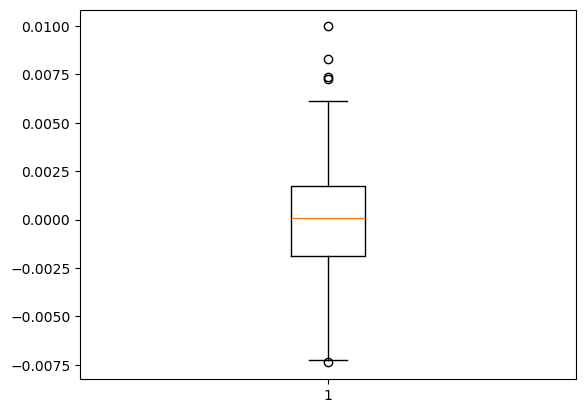

In [70]:
# plt.figure()
# plt.boxplot(F_j_mean_diff[:,0,0])
# # F_j_mean_diff.shape

In [57]:
# F_j_mean_diff.shape

(500, 20, 64)

(array([ 14.,  29.,  64., 107., 139.,  83.,  43.,  17.,   2.,   2.]),
 array([-0.00737825, -0.00564306, -0.00390787, -0.00217269, -0.0004375 ,
         0.00129769,  0.00303287,  0.00476806,  0.00650325,  0.00823843,
         0.00997362]),
 <BarContainer object of 10 artists>)

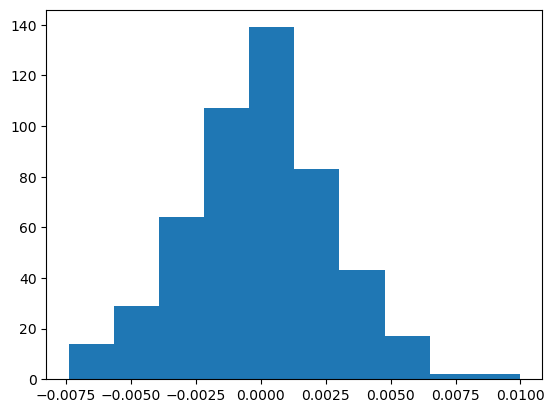

In [58]:
# plt.figure()
# plt.hist(F_j_mean_diff[:,0,0])

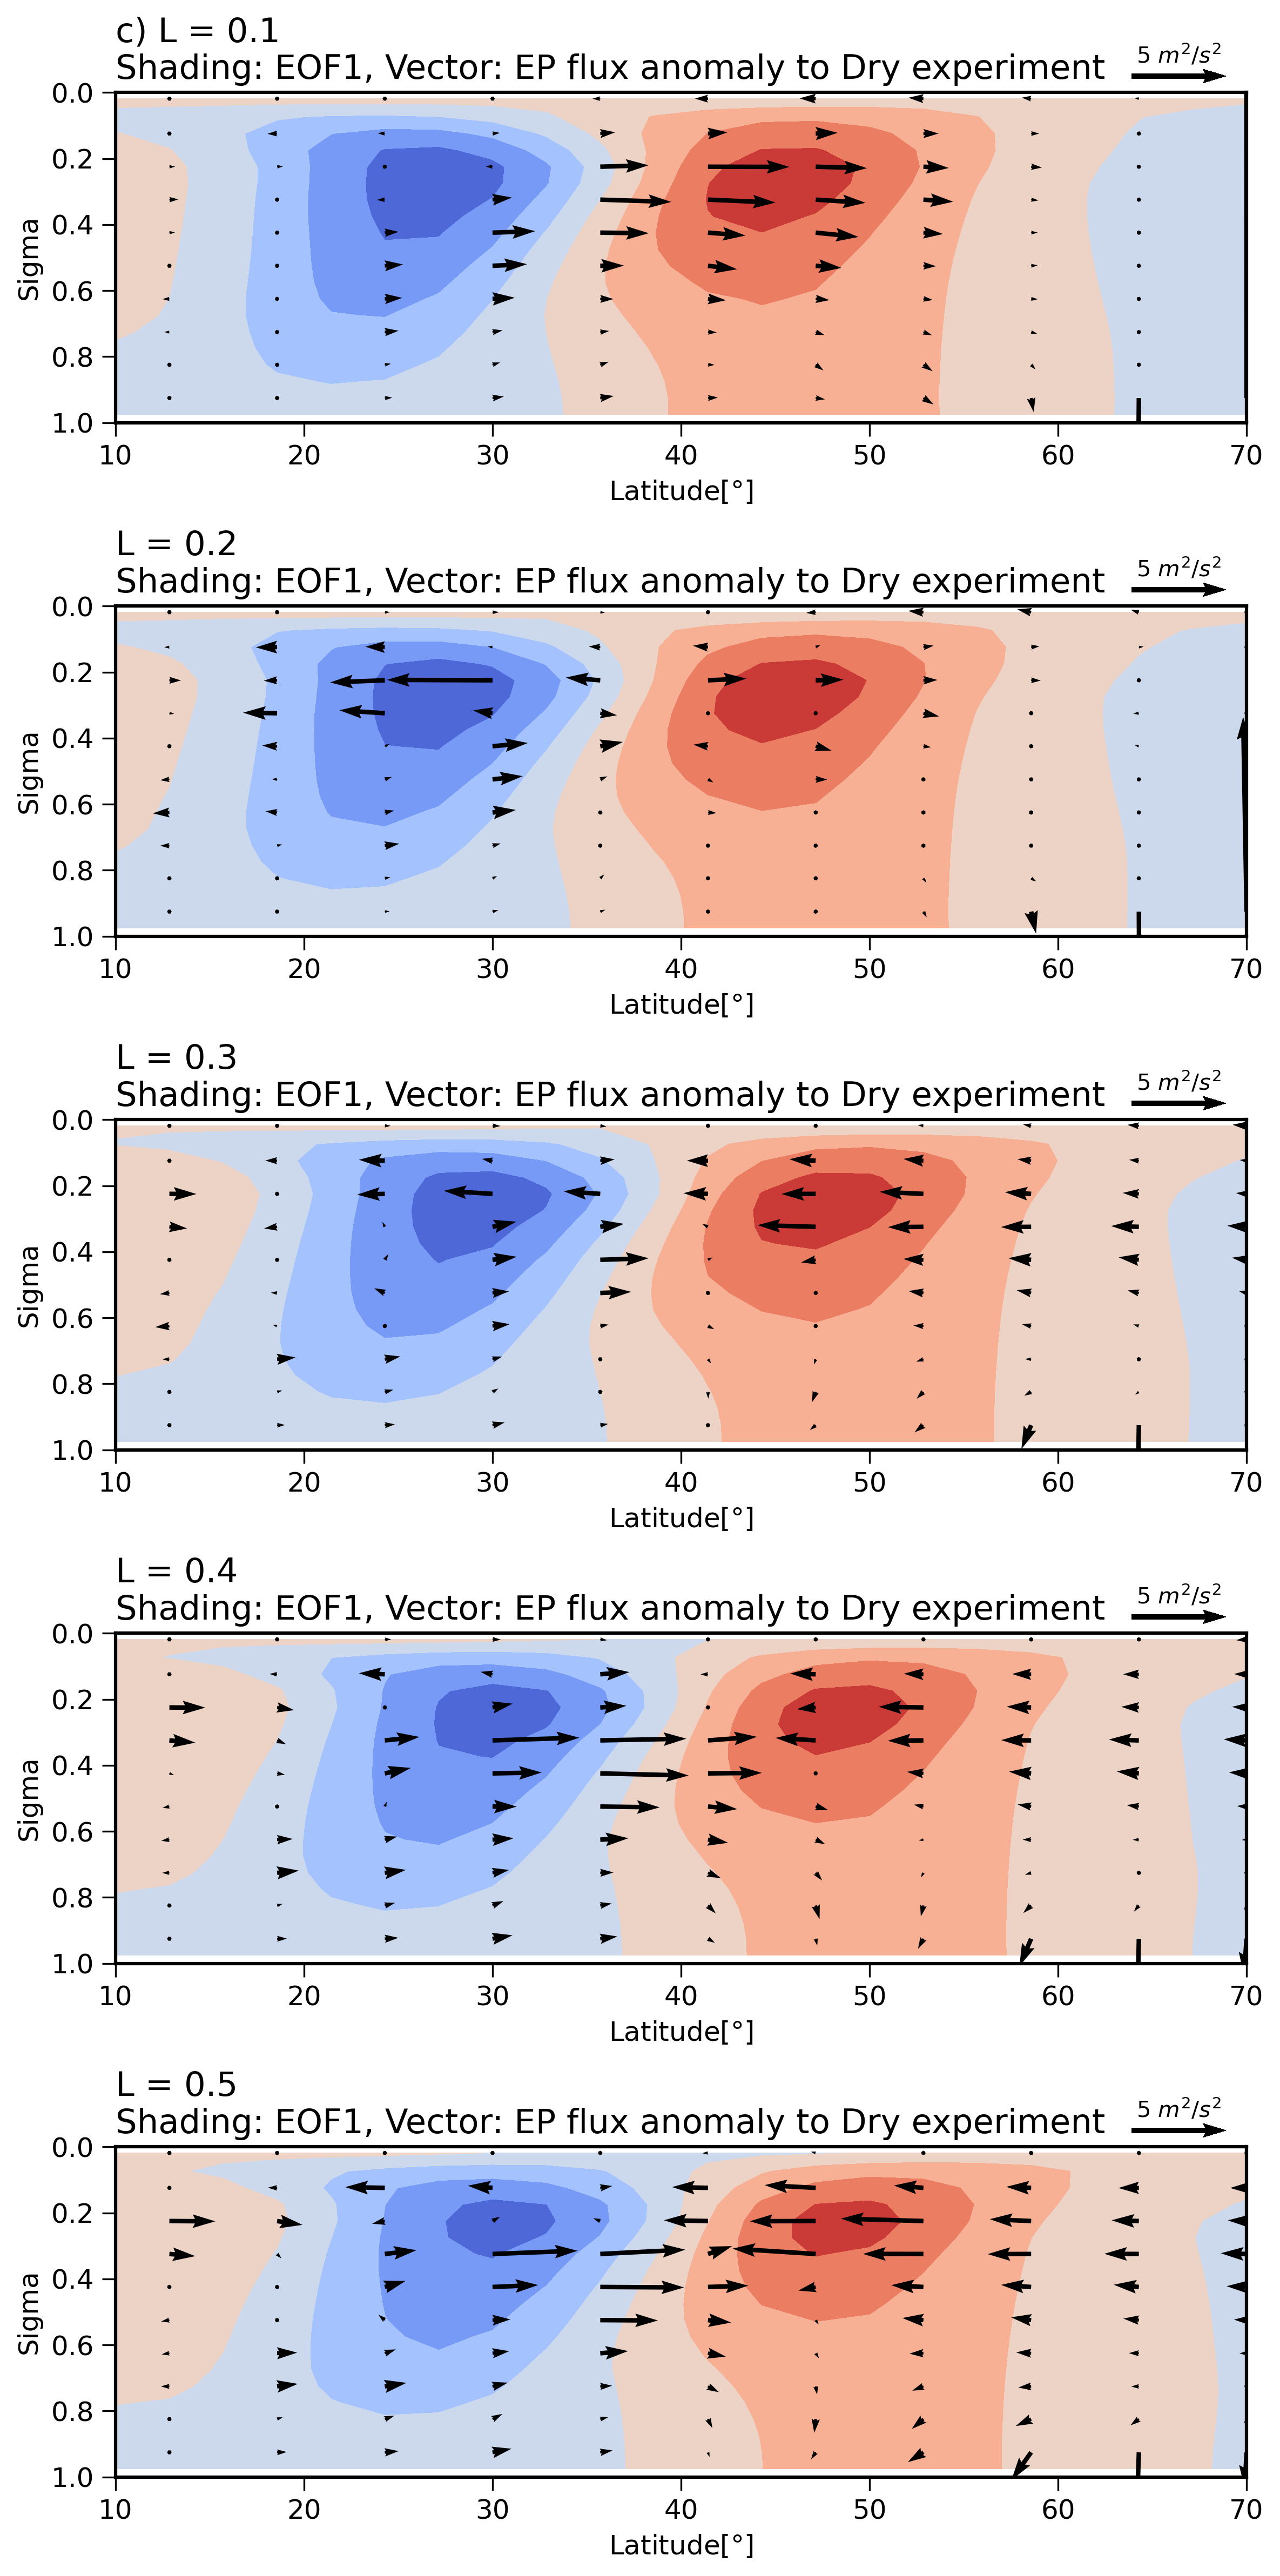

In [72]:
# def load_EOF(PR, save_dir):
#     EOF1 = np.load(f"{save_dir}/EOF1_PR_{PR}.npy")
#     return EOF1
# PR_values = range(10, 60, 10)
# # Constants
# f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90, 90, 64)))
# g = 9.81

# # PR values and lags to process
# lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
# lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days
# save_dir          = "EP_flux_results"       # Directory to save results
# pc1_save_dir      = "PC1_results"           # Directory to save PC1 results
# time_idx_save_dir = "time_idx_results"      # Directory to save time_idx results
# ep_flux_mean_dir  = "EP_flux_mean_results"  # Directory to save mean EP flux results
# # Step 3: Plotting the difference in EP flux between lag = 5-20 day mean and lag = 30-60 day mean
# fig, axes = plt.subplots(int(len(PR_values)), 1, figsize=(8, 16), dpi=300)

# # load the EP flux components
# F_j_mean_diff_PR0 = np.load(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_0.npy"))
# F_k_mean_diff_PR0 = np.load(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_0.npy"))

# NH_idx = 32
# threshold = 0  # Wind speed threshold in m/s
# import matplotlib as mpl
# mpl.rcParams['axes.linewidth'] = 1.5

# for j, PR in enumerate(PR_values):
#     # j = j-1
#     F_j_mean_diff = np.load(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_{PR}.npy"))
#     F_k_mean_diff = np.load(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_{PR}.npy"))

#     # Load sigma for contour plotting
#     sigma_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/sigma/PR{PR}_500_20000day_6hourly_sigma_only_z.dat"
#     with h5py.File(sigma_file, "r") as sigma_file0:
#         sigma = np.asarray(sigma_file0["sigma"][:])

#     y = np.linspace(-90, 90, 64)
#     yy, zz = np.meshgrid(y, sigma)

#     # Plot the difference in EP flux
#     ax = axes[j]
#     EOF1_PRs = load_EOF(PR, "PC1_results")
#     ax.contourf(yy[:,32:], zz[:,32:], -EOF1_PRs, cmap='coolwarm')
#     F_j_diff_final = (F_j_mean_diff[::, NH_idx::] - F_j_mean_diff_PR0[::, NH_idx::])
#     F_k_diff_final = (F_k_mean_diff[::, NH_idx::] - F_k_mean_diff_PR0[::, NH_idx::])

#     # Calculate wind speeds and create a mask for speeds below the threshold
#     wind_speed = np.sqrt(F_j_diff_final**2 + F_k_diff_final**2)
#     mask = (wind_speed >= threshold) | (wind_speed <= -threshold)
    
#     # Apply the mask to filter out low-speed arrows
#     F_j_diff_final = np.where(mask, F_j_diff_final, np.nan)
#     F_k_diff_final = np.where(mask, F_k_diff_final, np.nan)

    

#     wind_plt = ax.quiver(yy[::2, NH_idx::2], zz[::2, NH_idx::2], F_j_diff_final[::2, ::2], F_k_diff_final[::2, ::2],
#               color="black", scale_units='xy', angles='xy', width=4e-3, scale=2)
#     # ax.quiver(yy[::2, ::2], zz[::2, ::2], -(F_j_mean_diff[::2, ::2]), -(F_k_mean_diff[::2, ::2]),
#               # color="black", scale_units='xy', angles='xy', width=4e-3, scale=2)

#     ax.quiverkey(wind_plt,0.94,1.05,10,r'5 $m^2/s^2$',labelpos='N', labelsep =0.05, color='black')
    
#     ax.set_ylim([1, 0])
#     ax.set_xlim([10,70])
#     # ax.set_title(f"L = {PR * 0.01}: " + "EOF([$\overline{u}$]) anomaly between L = Dry in EP Flux [$m^2/s^2$]", fontsize=13, loc="left")
#     if PR == 10:
#         ax.set_title(f"c) L = {PR * 0.01} \n" + "Shading: EOF1, Vector: EP flux anomaly to Dry experiment", fontsize=15, loc="left")
#     else:
#         ax.set_title(f"L = {PR * 0.01} \n" + "Shading: EOF1, Vector: EP flux anomaly to Dry experiment", fontsize=15, loc="left")
#     ax.set_xlabel("Latitude[$\degree$]", fontsize=12)
#     ax.set_ylabel("Sigma", fontsize=12)
#     ax.tick_params(axis='x', labelsize=12)
#     ax.tick_params(axis='y', labelsize=12)
#     ax.tick_params(direction='out', length=6)
    
    


# plt.tight_layout()
# # plt.suptitle("EP Flux Anomaly Between Lag Ranges Fig.4-1", fontsize=18, y=1.02)
# # plt.savefig("113-1Seminar_fig/visualize/EPflux/anamoly.png", bbox_inches='tight', dpi=300.)
# plt.show()

In [ ]:
"""
做500次：
（在[L = 0.1 or L = Dry]去隨機選L=0.1.shape的數量的EP flux） - （在[L = 0.1 or L = Dry]去L=Dry.shape 數量EP flux）
    [兩個pool先選一個]              1000                             看前面選到哪個就是那個   500

在[L = 0.1]去隨機選L=0.1.shape的數量的EP flux: 3/26 done
在[L = Dry]去隨機選L=Dry.shape的數量的EP flux: 3/26 done

在[L = 0.1]去隨機選L=Dry.shape的數量的EP flux: unfinish
在[L = Dry]去隨機選L=0.1.shape的數量的EP flux: unfinish


"""


In [ ]:
"""
做500次：
（在[L = 0.1 or L = Dry]去隨機選L=0.1.shape的數量的EP flux） - （在[L = 0.1 or L = Dry]去L=Dry.shape 數量EP flux）
    [兩個pool先選一個]              1000                             看前面選到哪個就是那個   500
"""

"""
EP flux step 
1. Calculate PC1
2. Find PC1_positive_idx, PC1_negative_idx (e.g. 3000, 3500 for L = Dry)
3. Calculate EP flux with lag5~20 and lag90~100 and save them
4. Calculate EP flux lag5~20 mean - lag90~100 mean across experience = EP_Flux_diff (diff-> lag5~20 mean and lag90~100)
5. plot (EP_Flux_diff)_{L=0.1~0.5} - (EP_Flux_diff)_{L=Dry}
"""

In [ ]:
"""
Calculate 在[L = Dry]去隨機選L=0.1.shape的數量的EP flux: unfinish

"""


# Function to calculate EOF and PC
def Cal_EOF_PC(input_data):
    from EOF import EOF
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[2]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="2D")
    eof_instance.get()

    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]
    PC1_std = PC1.std()
    
    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm.reshape(20,32), PC1_norm, EOF2_norm.reshape(20,32), PC2_norm, eof_instance.explained[:10], PC1_std

# Function to read data from HDF5
def Read_var_simple(var, PR):
    str_var = str(var)
    common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
    last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
    with h5py.File(common_path + last_path, 'r') as file:
        data = np.asarray(file[str_var][:])
    return data

# Function to load saved components
def load_lagged_components(PR, lag, save_dir, suffix, num_sample):
    F_j_lag = np.load(f"{save_dir}/F_j_lag_{lag}_PR_{PR}_{suffix}_{num_sample}_samplings.npy")
    F_k_lag = np.load(f"{save_dir}/F_k_lag_{lag}_PR_{PR}_{suffix}_{num_sample}_samplings.npy")
    return F_j_lag, F_k_lag

# # Function to calculate and save lagged components for given time indices
# def calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx, suffix, num_sample):
#     # Read zonal mean variables
#     theta_zonal_mean_all = Read_var_simple("theta", PR)
#     dtheta_all           = Read_var_simple("dtheta", PR)
#     dz_all               = Read_var_simple("dz", PR)
#     v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
#     EMF_all              = Read_var_simple("EMF", PR)

#     # Calculate N squared
#     dthetadz_all = dtheta_all / dz_all
#     N_square_all = g / theta_zonal_mean_all * dthetadz_all

#     # Calculate lagged indices
#     # time_idx_lag = np.asarray(time_idx) + lag
#     time_idx_lag = time_idx[0] + lag
    
#     z_idx, y_idx = theta_zonal_mean_all.shape[1], theta_zonal_mean_all.shape[2]

#     theta_zonal_mean_lag = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     dtheta_lag           = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     dz_lag               = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     v_prime_b_prime_lag  = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     EMF_lag              = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))

#     F_j_lag_num_sampling = np.zeros((num_sample, z_idx, y_idx))
#     F_k_lag_num_sampling = np.zeros((num_sample, z_idx, y_idx))
    
#     for ens in range(num_sample):
#         for i in range(len(time_idx[0])):
#             theta_zonal_mean_lag[i] = theta_zonal_mean_all[int(time_idx_lag[i]), :, :] 
#             dtheta_lag[i]           = dtheta_all[int(time_idx_lag[i]), :, :] 
#             dz_lag[i]               = dz_all[int(time_idx_lag[i]), :, :]
#             v_prime_b_prime_lag[i]  = v_prime_b_prime_all[int(time_idx_lag[i]), :, :] 
#             EMF_lag[i]              = EMF_all[int(time_idx_lag[i]), :, :] 
    
#         dthetadz_lag = dtheta_lag / dz_lag
#         N_square_lag = g / theta_zonal_mean_lag * dthetadz_lag
    
#         F_j_long_time_mean = EMF_all.mean(axis=0)
#         F_k_long_time_mean = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_all / N_square_all).mean(axis=0) 
        
#         F_j_lag[ens] = EMF_lag.mean(axis=0) - F_j_long_time_mean
#         F_k_lag[ens] = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_lag / N_square_lag).mean(axis=0) - F_k_long_time_mean
    
#         # Save the results
#     os.makedirs(save_dir, exist_ok=True)
#     np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_j_lag_num_sampling)
#     np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_k_lag_num_sampling)
#     print(f"Saved F_j and F_k for PR={PR}, lag={lag}, condition={suffix}")

def calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx, suffix, num_sample):
    # Read zonal mean variables
    theta_zonal_mean_all = Read_var_simple("theta", PR)
    dtheta_all           = Read_var_simple("dtheta", PR)
    dz_all               = Read_var_simple("dz", PR)
    vpbp_all             = Read_var_simple("v_prime_b_prime", PR)
    EMF_all              = Read_var_simple("EMF", PR)

    # Precompute long-time means and N²
    dthetadz_all = dtheta_all / dz_all
    N2_all = g / theta_zonal_mean_all * dthetadz_all

    F_j_mean = EMF_all.mean(axis=0)
    F_k_mean = (f0[np.newaxis, np.newaxis, :] * vpbp_all / N2_all).mean(axis=0)

    sel_time_size = time_idx.shape[1] # (500, time_positive_inddex.shape)
    
    # Get lagged time indices
    time_idx_lagged = (time_idx + lag).astype(int)
    print(time_idx_lagged.shape)
    time_idx_lagged = np.clip(time_idx_lagged, 0, theta_zonal_mean_all.shape[0] - 1)
    
    # Vectorized data extraction
    theta_lag = theta_zonal_mean_all[time_idx_lagged]
    dtheta_lag = dtheta_all[time_idx_lagged]
    dz_lag = dz_all[time_idx_lagged]
    vpbp_lag = vpbp_all[time_idx_lagged]
    EMF_lag = EMF_all[time_idx_lagged]

    # Reshape to (num_sample, num_times, z, y)
    theta_lag = theta_lag.reshape((num_sample, *theta_lag.shape[1:]))
    dtheta_lag = dtheta_lag.reshape((num_sample, *dtheta_lag.shape[1:]))
    dz_lag = dz_lag.reshape((num_sample, *dz_lag.shape[1:]))
    vpbp_lag = vpbp_lag.reshape((num_sample, *vpbp_lag.shape[1:]))
    EMF_lag = EMF_lag.reshape((num_sample, *EMF_lag.shape[1:]))

    # Compute lagged N²
    N2_lag = g / theta_lag * (dtheta_lag / dz_lag)

    # Mean over time dimension
    EMF_lag_mean = EMF_lag.mean(axis=1)
    F_j_lag = EMF_lag_mean - F_j_mean

    F_k_lag_mean = (f0[np.newaxis, np.newaxis, :] * vpbp_lag / N2_lag).mean(axis=1)
    F_k_lag = F_k_lag_mean - F_k_mean

    # Save the result
    os.makedirs(save_dir, exist_ok=True)
    # np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_j_lag)
    # np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_k_lag)
    
    np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings_with_dry_exp_diff_shape.npy"), F_j_lag)
    np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings_with_dry_exp_diff_shape.npy"), F_k_lag)
    print(f"✅ Saved lagged components for PR={PR}, lag={lag}, condition={suffix}")




# Constants
f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90, 90, 64)))
g = 9.81

# PR values and lags to process
PR_values  = range(0, 60, 10)
lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days
save_dir          = "EP_flux_statistical_test/dry_EP_flux_with_diff_shape/EP_flux_results"       # Directory to save results
pc1_save_dir      = "EP_flux_statistical_test/dry_EP_flux_with_diff_shape/PC1_results"           # Directory to save PC1 results
time_idx_save_dir = "EP_flux_statistical_test/dry_EP_flux_with_diff_shape/time_idx_results"      # Directory to save time_idx results
ep_flux_mean_dir  = "EP_flux_statistical_test/dry_EP_flux_with_diff_shape/EP_flux_mean_results"  # Directory to save mean EP flux results

# Storage for EOFs and PCs across different PR values
EOF1_all_PRs = {}
EOF2_all_PRs = {}
PC1_all_PRs = {}
PC2_all_PRs = {}
explained_variance_PRs = {}
time_idx_PRs = {}
PC1_std_PRs = {}

# Ensure the mean EP flux directory exists
os.makedirs(ep_flux_mean_dir, exist_ok=True)

# Function to calculate mean EP flux over specified lags
def calculate_mean_flux(PR, lags, suffix, num_sample):
    F_j_mean = np.zeros_like(np.load(f"{save_dir}/F_j_lag_{lags[0]}_PR_{PR}_positive_{num_sample}_samplings.npy"))
    F_k_mean = np.zeros_like(np.load(f"{save_dir}/F_k_lag_{lags[0]}_PR_{PR}_positive_{num_sample}_samplings.npy"))
    
    for lag in lags:
        F_j_positive, F_k_positive = load_lagged_components(PR, lag, save_dir, "positive", num_sample)
        F_j_negative, F_k_negative = load_lagged_components(PR, lag, save_dir, "negative", num_sample)
        
        F_j_mean += (F_j_positive - F_j_negative) 
        F_k_mean += (F_k_positive - F_k_negative) 
    
    F_j_mean /= len(lags)
    F_k_mean /= len(lags)
    
    np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_{suffix}_PR_{PR}_{num_sample}_sampling.npy"), F_j_mean)
    np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_{suffix}_PR_{PR}_{num_sample}_sampling.npy"), F_k_mean)

    return F_j_mean, F_k_mean

num_sample = 500
# Step 1: Calculate and save lagged components for each PR and lag
for PR in PR_values:
    print(f"Processing PR = {PR}")
    """
    # Read the U data for the current PR
    u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u_zonal_mean.h5"
    with h5py.File(u_file, "r") as u_file0:
        u_data = np.asarray(u_file0["u"][:,:])
    
    # Calculate EOFs and PCs for the current PR
    EOF1, PC1, EOF2, PC2, explained_variance, PC1_std = Cal_EOF_PC(u_data[:,:,32:])
    
    # Normalize the sign of EOF1
    if PR > 0:  # Assuming PR=0 is the baseline
        sign_correction = np.sign(np.dot(EOF1_all_PRs[PR_values[0]].reshape(-1), EOF1.reshape(-1)))
        EOF1 *= sign_correction
        PC1 *= sign_correction
    
    # Store the results
    EOF1_all_PRs[PR] = EOF1
    EOF2_all_PRs[PR] = EOF2
    PC1_all_PRs[PR] = PC1
    PC2_all_PRs[PR] = PC2
    explained_variance_PRs[PR] = explained_variance
    PC1_std_PRs[PR] = PC1_std
    
    # Save PC1 and EOF1 to file for later inspection
    os.makedirs(pc1_save_dir, exist_ok=True)
    np.save(os.path.join(pc1_save_dir, f"PC1_PR_{PR}.npy"), PC1)
    np.save(os.path.join(pc1_save_dir, f"EOF1_PR_{PR}.npy"), EOF1)
    np.save(os.path.join(pc1_save_dir, f"PC1_std_PR_{PR}.npy"), PC1_std)
    """
    PC1_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PC1_results/PC1_PR_{PR}.npy"
    
    PC1 = np.asarray(np.load(PC1_file))
    # Calculate time_idx for PC1 > 1*std
    time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
    time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
    
    # Adjust time_idx values if they exceed the limit
    max_idx = int(78000 - 100*4)
    time_idx_array_positive = time_idx_positive[time_idx_positive <= max_idx]
    time_idx_array_negative = time_idx_negative[time_idx_negative <= max_idx]

    time_idx_array_positive_stat = np.zeros((500, time_idx_array_positive.shape[0]))
    time_idx_array_negative_stat = np.zeros((500, time_idx_array_negative.shape[0]))

    # np.random.seed(0)
    # for ens in range(2,num_sample):
        # time_idx_array_positive_stat[int(PR//10), ens] = (np.random.choice(78000 - 4 * 100,time_idx_array_positive.shape[0], replace=False))  # time_idx_positive[time_idx_positive <= max_idx]
        # time_idx_array_negative_stat[int(PR//10), ens] = (np.random.choice(78000 - 4 * 100,time_idx_array_negative.shape[0], replace=False))  # time_idx_negative[time_idx_negative <= max_idx]

    time_idx_array_positive_stat[:,:] = np.random.randint(0, 78000 - 4 * 100, size=(num_sample, time_idx_array_positive.shape[0]))
    time_idx_array_negative_stat[:,:] = np.random.randint(0, 78000 - 4 * 100, size=(num_sample, time_idx_array_negative.shape[0]))
    

    # Save time_idx for PC1 > 2*std and < -2*std
    # np.save(os.path.join(time_idx_save_dir, f"time_idx_positive_PR_{PR}.npy"), time_idx_array_positive)
    # np.save(os.path.join(time_idx_save_dir, f"time_idx_negative_PR_{PR}.npy"), time_idx_array_negative)

    # Use calculate_and_save_lagged_components for all necessary lags
    for lag in list(lags_5_20) + list(lags_30_60):
        # You would need the time indices (time_idx) for this step
        # time_idx = np.arange(78000)  # Assuming this is how you would set time_idx; adjust as needed
        # calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, (time_idx_array_positive_stat[int(PR//10)],), "positive", num_sample)
        # calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, (time_idx_array_negative_stat[int(PR//10)],), "negative", num_sample)

        calculate_and_save_lagged_components_stat(0, lag, f0, g, save_dir, time_idx_array_positive_stat[:], "positive", num_sample)
        calculate_and_save_lagged_components_stat(0, lag, f0, g, save_dir, time_idx_array_negative_stat[:], "negative", num_sample)

    print(f"Completed PR = {PR}, time_idx length: {len(time_idx_array_positive)} (positive), {len(time_idx_array_negative)} (negative)")
    
    




In [ ]:
"""
Calculate 在[L = 0.1]去隨機選L=Dry.shape的數量的EP flux: unfinish

"""


# Function to calculate EOF and PC
def Cal_EOF_PC(input_data):
    from EOF import EOF
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[2]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="2D")
    eof_instance.get()

    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]
    PC1_std = PC1.std()
    
    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm.reshape(20,32), PC1_norm, EOF2_norm.reshape(20,32), PC2_norm, eof_instance.explained[:10], PC1_std

# Function to read data from HDF5
def Read_var_simple(var, PR):
    str_var = str(var)
    common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
    last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
    with h5py.File(common_path + last_path, 'r') as file:
        data = np.asarray(file[str_var][:])
    return data

# Function to load saved components
def load_lagged_components(PR, lag, save_dir, suffix, num_sample):
    F_j_lag = np.load(f"{save_dir}/F_j_lag_{lag}_PR_{PR}_{suffix}_{num_sample}_samplings.npy")
    F_k_lag = np.load(f"{save_dir}/F_k_lag_{lag}_PR_{PR}_{suffix}_{num_sample}_samplings.npy")
    return F_j_lag, F_k_lag

# # Function to calculate and save lagged components for given time indices
# def calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx, suffix, num_sample):
#     # Read zonal mean variables
#     theta_zonal_mean_all = Read_var_simple("theta", PR)
#     dtheta_all           = Read_var_simple("dtheta", PR)
#     dz_all               = Read_var_simple("dz", PR)
#     v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
#     EMF_all              = Read_var_simple("EMF", PR)

#     # Calculate N squared
#     dthetadz_all = dtheta_all / dz_all
#     N_square_all = g / theta_zonal_mean_all * dthetadz_all

#     # Calculate lagged indices
#     # time_idx_lag = np.asarray(time_idx) + lag
#     time_idx_lag = time_idx[0] + lag
    
#     z_idx, y_idx = theta_zonal_mean_all.shape[1], theta_zonal_mean_all.shape[2]

#     theta_zonal_mean_lag = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     dtheta_lag           = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     dz_lag               = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     v_prime_b_prime_lag  = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     EMF_lag              = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))

#     F_j_lag_num_sampling = np.zeros((num_sample, z_idx, y_idx))
#     F_k_lag_num_sampling = np.zeros((num_sample, z_idx, y_idx))
    
#     for ens in range(num_sample):
#         for i in range(len(time_idx[0])):
#             theta_zonal_mean_lag[i] = theta_zonal_mean_all[int(time_idx_lag[i]), :, :] 
#             dtheta_lag[i]           = dtheta_all[int(time_idx_lag[i]), :, :] 
#             dz_lag[i]               = dz_all[int(time_idx_lag[i]), :, :]
#             v_prime_b_prime_lag[i]  = v_prime_b_prime_all[int(time_idx_lag[i]), :, :] 
#             EMF_lag[i]              = EMF_all[int(time_idx_lag[i]), :, :] 
    
#         dthetadz_lag = dtheta_lag / dz_lag
#         N_square_lag = g / theta_zonal_mean_lag * dthetadz_lag
    
#         F_j_long_time_mean = EMF_all.mean(axis=0)
#         F_k_long_time_mean = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_all / N_square_all).mean(axis=0) 
        
#         F_j_lag[ens] = EMF_lag.mean(axis=0) - F_j_long_time_mean
#         F_k_lag[ens] = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_lag / N_square_lag).mean(axis=0) - F_k_long_time_mean
    
#         # Save the results
#     os.makedirs(save_dir, exist_ok=True)
#     np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_j_lag_num_sampling)
#     np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_k_lag_num_sampling)
#     print(f"Saved F_j and F_k for PR={PR}, lag={lag}, condition={suffix}")

def calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx, suffix, num_sample):
    # Read zonal mean variables
    theta_zonal_mean_all = Read_var_simple("theta", PR)
    dtheta_all           = Read_var_simple("dtheta", PR)
    dz_all               = Read_var_simple("dz", PR)
    vpbp_all             = Read_var_simple("v_prime_b_prime", PR)
    EMF_all              = Read_var_simple("EMF", PR)

    # Precompute long-time means and N²
    dthetadz_all = dtheta_all / dz_all
    N2_all = g / theta_zonal_mean_all * dthetadz_all

    F_j_mean = EMF_all.mean(axis=0)
    F_k_mean = (f0[np.newaxis, np.newaxis, :] * vpbp_all / N2_all).mean(axis=0)

    sel_time_size = time_idx.shape[1] # (500, time_positive_inddex.shape)
    
    # Get lagged time indices
    time_idx_lagged = (time_idx + lag).astype(int)
    print(time_idx_lagged.shape)
    time_idx_lagged = np.clip(time_idx_lagged, 0, theta_zonal_mean_all.shape[0] - 1)
    
    # Vectorized data extraction
    theta_lag = theta_zonal_mean_all[time_idx_lagged]
    dtheta_lag = dtheta_all[time_idx_lagged]
    dz_lag = dz_all[time_idx_lagged]
    vpbp_lag = vpbp_all[time_idx_lagged]
    EMF_lag = EMF_all[time_idx_lagged]

    # Reshape to (num_sample, num_times, z, y)
    theta_lag = theta_lag.reshape((num_sample, *theta_lag.shape[1:]))
    dtheta_lag = dtheta_lag.reshape((num_sample, *dtheta_lag.shape[1:]))
    dz_lag = dz_lag.reshape((num_sample, *dz_lag.shape[1:]))
    vpbp_lag = vpbp_lag.reshape((num_sample, *vpbp_lag.shape[1:]))
    EMF_lag = EMF_lag.reshape((num_sample, *EMF_lag.shape[1:]))

    # Compute lagged N²
    N2_lag = g / theta_lag * (dtheta_lag / dz_lag)

    # Mean over time dimension
    EMF_lag_mean = EMF_lag.mean(axis=1)
    F_j_lag = EMF_lag_mean - F_j_mean

    F_k_lag_mean = (f0[np.newaxis, np.newaxis, :] * vpbp_lag / N2_lag).mean(axis=1)
    F_k_lag = F_k_lag_mean - F_k_mean

    # Save the result
    os.makedirs(save_dir, exist_ok=True)
    # np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_j_lag)
    # np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_k_lag)
    np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings_with_diff_exp_dry_shape.npy"), F_j_lag)
    np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings_with_diff_exp_dry_shape.npy"), F_k_lag)

    
    print(f"✅ Saved lagged components for PR={PR}, lag={lag}, condition={suffix}")




# Constants
f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90, 90, 64)))
g = 9.81

# PR values and lags to process
PR_values  = range(0, 60, 10)
lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days
save_dir          = "EP_flux_statistical_test/diff_EP_flux_with_dry_shape/EP_flux_results"       # Directory to save results
pc1_save_dir      = "EP_flux_statistical_test/diff_EP_flux_with_dry_shape/PC1_results"           # Directory to save PC1 results
time_idx_save_dir = "EP_flux_statistical_test/diff_EP_flux_with_dry_shape/time_idx_results"      # Directory to save time_idx results
ep_flux_mean_dir  = "EP_flux_statistical_test/diff_EP_flux_with_dry_shape/EP_flux_mean_results"  # Directory to save mean EP flux results

# Storage for EOFs and PCs across different PR values
EOF1_all_PRs = {}
EOF2_all_PRs = {}
PC1_all_PRs = {}
PC2_all_PRs = {}
explained_variance_PRs = {}
time_idx_PRs = {}
PC1_std_PRs = {}

# Ensure the mean EP flux directory exists
os.makedirs(ep_flux_mean_dir, exist_ok=True)

# Function to calculate mean EP flux over specified lags
def calculate_mean_flux(PR, lags, suffix, num_sample):
    F_j_mean = np.zeros_like(np.load(f"{save_dir}/F_j_lag_{lags[0]}_PR_{PR}_positive_{num_sample}_samplings.npy"))
    F_k_mean = np.zeros_like(np.load(f"{save_dir}/F_k_lag_{lags[0]}_PR_{PR}_positive_{num_sample}_samplings.npy"))
    
    for lag in lags:
        F_j_positive, F_k_positive = load_lagged_components(PR, lag, save_dir, "positive", num_sample)
        F_j_negative, F_k_negative = load_lagged_components(PR, lag, save_dir, "negative", num_sample)
        
        F_j_mean += (F_j_positive - F_j_negative) 
        F_k_mean += (F_k_positive - F_k_negative) 
    
    F_j_mean /= len(lags)
    F_k_mean /= len(lags)
    
    np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_{suffix}_PR_{PR}_{num_sample}_sampling.npy"), F_j_mean)
    np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_{suffix}_PR_{PR}_{num_sample}_sampling.npy"), F_k_mean)

    return F_j_mean, F_k_mean

num_sample = 500
# Step 1: Calculate and save lagged components for each PR and lag
for PR in PR_values:
    print(f"Processing PR = {PR}")
    """
    # Read the U data for the current PR
    u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u_zonal_mean.h5"
    with h5py.File(u_file, "r") as u_file0:
        u_data = np.asarray(u_file0["u"][:,:])
    
    # Calculate EOFs and PCs for the current PR
    EOF1, PC1, EOF2, PC2, explained_variance, PC1_std = Cal_EOF_PC(u_data[:,:,32:])
    
    # Normalize the sign of EOF1
    if PR > 0:  # Assuming PR=0 is the baseline
        sign_correction = np.sign(np.dot(EOF1_all_PRs[PR_values[0]].reshape(-1), EOF1.reshape(-1)))
        EOF1 *= sign_correction
        PC1 *= sign_correction
    
    # Store the results
    EOF1_all_PRs[PR] = EOF1
    EOF2_all_PRs[PR] = EOF2
    PC1_all_PRs[PR] = PC1
    PC2_all_PRs[PR] = PC2
    explained_variance_PRs[PR] = explained_variance
    PC1_std_PRs[PR] = PC1_std
    
    # Save PC1 and EOF1 to file for later inspection
    os.makedirs(pc1_save_dir, exist_ok=True)
    np.save(os.path.join(pc1_save_dir, f"PC1_PR_{PR}.npy"), PC1)
    np.save(os.path.join(pc1_save_dir, f"EOF1_PR_{PR}.npy"), EOF1)
    np.save(os.path.join(pc1_save_dir, f"PC1_std_PR_{PR}.npy"), PC1_std)
    """
    PC1_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PC1_results/PC1_PR_0.npy"
    
    PC1 = np.asarray(np.load(PC1_file))
    # Calculate time_idx for PC1 > 1*std
    time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
    time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
    
    # Adjust time_idx values if they exceed the limit
    max_idx = int(78000 - 100*4)
    time_idx_array_positive = time_idx_positive[time_idx_positive <= max_idx]
    time_idx_array_negative = time_idx_negative[time_idx_negative <= max_idx]

    time_idx_array_positive_stat = np.zeros((500, time_idx_array_positive.shape[0]))
    time_idx_array_negative_stat = np.zeros((500, time_idx_array_negative.shape[0]))

    # np.random.seed(0)
    # for ens in range(2,num_sample):
        # time_idx_array_positive_stat[int(PR//10), ens] = (np.random.choice(78000 - 4 * 100,time_idx_array_positive.shape[0], replace=False))  # time_idx_positive[time_idx_positive <= max_idx]
        # time_idx_array_negative_stat[int(PR//10), ens] = (np.random.choice(78000 - 4 * 100,time_idx_array_negative.shape[0], replace=False))  # time_idx_negative[time_idx_negative <= max_idx]

    time_idx_array_positive_stat[:,:] = np.random.randint(0, 78000 - 4 * 100, size=(num_sample, time_idx_array_positive.shape[0]))
    time_idx_array_negative_stat[:,:] = np.random.randint(0, 78000 - 4 * 100, size=(num_sample, time_idx_array_negative.shape[0]))
    

    # Save time_idx for PC1 > 2*std and < -2*std
    # np.save(os.path.join(time_idx_save_dir, f"time_idx_positive_PR_{PR}.npy"), time_idx_array_positive)
    # np.save(os.path.join(time_idx_save_dir, f"time_idx_negative_PR_{PR}.npy"), time_idx_array_negative)

    # Use calculate_and_save_lagged_components for all necessary lags
    for lag in list(lags_5_20) + list(lags_30_60):
        # You would need the time indices (time_idx) for this step
        # time_idx = np.arange(78000)  # Assuming this is how you would set time_idx; adjust as needed
        # calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, (time_idx_array_positive_stat[int(PR//10)],), "positive", num_sample)
        # calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, (time_idx_array_negative_stat[int(PR//10)],), "negative", num_sample)

        calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx_array_positive_stat[:], "positive", num_sample)
        calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx_array_negative_stat[:], "negative", num_sample)

    print(f"Completed PR = {PR}, time_idx length: {len(time_idx_array_positive)} (positive), {len(time_idx_array_negative)} (negative)")
    
    




# Calculate EP flux with L=Dry N^2 across experiences

In [53]:
# """
# ep_flux_mean_dir_1_1: Fig.4-1 lags_5_20: np.linspace(5*4,20*4,1)
# ep_flux_mean_dir    : Fig.4-1 lags_5_20: np.linspace(15*4,20*4,1)
# ep_flux_mean_dir_1_2: Fig.4-2 dot
# ep_flux_mean_dir_1_3: Fig.4-2 dot after doing chunk

# """


# # Function to calculate EOF and PC
# def Cal_EOF_PC(input_data):
#     from EOF import EOF
    
#     # Perform latitude weighting
#     input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[2]))))

#     # Initialize an EOF instance with weighted input data
#     n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

#     eof_instance = EOF((input_data_weighted,), n_components=n_component, field="2D")
#     eof_instance.get()

#     # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
#     EOF1, EOF2 = eof_instance.EOF[:2]
#     PC1, PC2 = eof_instance.PC[:2]
#     PC1_std = PC1.std()
    
#     # Normalize PCs and EOFs
#     PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
#     EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
#     return EOF1_norm.reshape(20,32), PC1_norm, EOF2_norm.reshape(20,32), PC2_norm, eof_instance.explained[:10], PC1_std

# # Function to read data from HDF5
# def Read_var_simple(var, PR):
#     str_var = str(var)
#     common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
#     last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
#     with h5py.File(common_path + last_path, 'r') as file:
#         data = np.asarray(file[str_var][:])
#     return data

# # Function to load saved components
# def load_lagged_components(PR, lag, save_dir, suffix):
#     F_j_lag = np.load(f"{save_dir}/F_j_lag_{lag}_PR_{PR}_{suffix}.npy")
#     F_k_lag = np.load(f"{save_dir}/F_k_lag_{lag}_PR_{PR}_{suffix}.npy")
#     return F_j_lag, F_k_lag

# # Function to calculate and save lagged components for given time indices
# def calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, time_idx, suffix):
#     # Read zonal mean variables
#     theta_zonal_mean_all = Read_var_simple("theta", 0)
#     dtheta_all           = Read_var_simple("dtheta", 0)
#     dz_all               = Read_var_simple("dz", 0)
#     v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
#     EMF_all              = Read_var_simple("EMF", PR)

#     # Calculate N squared
#     dthetadz_all = dtheta_all / dz_all
#     N_square_all = g / theta_zonal_mean_all * dthetadz_all

#     # Calculate lagged indices
#     time_idx_lag = np.asarray(time_idx) + lag
#     z_idx, y_idx = theta_zonal_mean_all.shape[1], theta_zonal_mean_all.shape[2]

#     theta_zonal_mean_lag = np.zeros((len(time_idx[0]), z_idx, y_idx))
#     dtheta_lag           = np.zeros((len(time_idx[0]), z_idx, y_idx))
#     dz_lag               = np.zeros((len(time_idx[0]), z_idx, y_idx))
#     v_prime_b_prime_lag  = np.zeros((len(time_idx[0]), z_idx, y_idx))
#     EMF_lag              = np.zeros((len(time_idx[0]), z_idx, y_idx))

#     for i in range(len(time_idx[0])):
#         theta_zonal_mean_lag[i] = theta_zonal_mean_all[time_idx_lag[0][i], :, :] 
#         dtheta_lag[i]           = dtheta_all[time_idx_lag[0][i], :, :] 
#         dz_lag[i]               = dz_all[time_idx_lag[0][i], :, :]
#         v_prime_b_prime_lag[i]  = v_prime_b_prime_all[time_idx_lag[0][i], :, :] 
#         EMF_lag[i]              = EMF_all[time_idx_lag[0][i], :, :] 

#     dthetadz_lag = dtheta_lag / dz_lag
#     N_square_lag = g / theta_zonal_mean_lag * dthetadz_lag

#     F_j_long_time_mean = EMF_all.mean(axis=0)
#     F_k_long_time_mean = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_all / N_square_all).mean(axis=0) 
    
#     F_j_lag = EMF_lag.mean(axis=0) - F_j_long_time_mean
#     F_k_lag = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_lag / N_square_lag).mean(axis=0) - F_k_long_time_mean

#     # Save the results
#     os.makedirs(save_dir, exist_ok=True)
#     np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}.npy"), F_j_lag)
#     np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}.npy"), F_k_lag)
#     print(f"Saved F_j and F_k for PR={PR}, lag={lag}, condition={suffix}")

# # Constants
# f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90, 90, 64)))
# g = 9.81

# # PR values and lags to process
# PR_values  = range(0, 60, 10)
# lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
# lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days
# save_dir          = "EP_flux_with_dry_N_square/EP_flux_results"       # Directory to save results
# pc1_save_dir      = "EP_flux_with_dry_N_square/PC1_results"           # Directory to save PC1 results
# time_idx_save_dir = "EP_flux_with_dry_N_square/time_idx_results"      # Directory to save time_idx results
# ep_flux_mean_dir  = "EP_flux_with_dry_N_square/EP_flux_mean_results"  # Directory to save mean EP flux results

# # Storage for EOFs and PCs across different PR values
# EOF1_all_PRs = {}
# EOF2_all_PRs = {}
# PC1_all_PRs = {}
# PC2_all_PRs = {}
# explained_variance_PRs = {}
# time_idx_PRs = {}
# PC1_std_PRs = {}

# # Ensure the mean EP flux directory exists
# os.makedirs(ep_flux_mean_dir, exist_ok=True)
# os.makedirs(time_idx_save_dir, exist_ok=True)


# # Function to calculate mean EP flux over specified lags
# def calculate_mean_flux(PR, lags, suffix):
#     F_j_mean = np.zeros_like(np.load(f"{save_dir}/F_j_lag_{lags[0]}_PR_{PR}_positive.npy"))
#     F_k_mean = np.zeros_like(np.load(f"{save_dir}/F_k_lag_{lags[0]}_PR_{PR}_positive.npy"))
    
#     for lag in lags:
#         F_j_positive, F_k_positive = load_lagged_components(PR, lag, save_dir, "positive")
#         F_j_negative, F_k_negative = load_lagged_components(PR, lag, save_dir, "negative")
        
#         F_j_mean += (F_j_positive - F_j_negative) 
#         F_k_mean += (F_k_positive - F_k_negative) 
    
#     F_j_mean /= len(lags)
#     F_k_mean /= len(lags)
    
#     np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_{suffix}_PR_{PR}.npy"), F_j_mean)
#     np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_{suffix}_PR_{PR}.npy"), F_k_mean)

#     return F_j_mean, F_k_mean

# # Step 1: Calculate and save lagged components for each PR and lag
# for PR in PR_values:
#     print(f"Processing PR = {PR} with dry N^2")
#     # Read the U data for the current PR
#     u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u_zonal_mean.h5"
#     with h5py.File(u_file, "r") as u_file0:
#         if PR == 0:
#             u_data = np.asarray(u_file0["u"][:,:]).mean(axis=-1)
#         else:
#             u_data = np.asarray(u_file0["u"][:,:])

    
#     # Calculate EOFs and PCs for the current PR
#     EOF1, PC1, EOF2, PC2, explained_variance, PC1_std = Cal_EOF_PC(u_data[:,:,32:])
    
#     # Normalize the sign of EOF1
#     if PR > 0:  # Assuming PR=0 is the baseline
#         sign_correction = np.sign(np.dot(EOF1_all_PRs[PR_values[0]].reshape(-1), EOF1.reshape(-1)))
#         EOF1 *= sign_correction
#         PC1 *= sign_correction
    
#     # Store the results
#     EOF1_all_PRs[PR] = EOF1
#     EOF2_all_PRs[PR] = EOF2
#     PC1_all_PRs[PR] = PC1
#     PC2_all_PRs[PR] = PC2
#     explained_variance_PRs[PR] = explained_variance
#     PC1_std_PRs[PR] = PC1_std
    
#     # Save PC1 and EOF1 to file for later inspection
#     os.makedirs(pc1_save_dir, exist_ok=True)
#     np.save(os.path.join(pc1_save_dir, f"PC1_PR_{PR}.npy"), PC1)
#     np.save(os.path.join(pc1_save_dir, f"EOF1_PR_{PR}.npy"), EOF1)
#     np.save(os.path.join(pc1_save_dir, f"PC1_std_PR_{PR}.npy"), PC1_std)
    
#     # Calculate time_idx for PC1 > 1*std
#     time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
#     time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
    
#     # Adjust time_idx values if they exceed the limit
#     max_idx = int(78000 - 100*4)
#     time_idx_array_positive = time_idx_positive[time_idx_positive <= max_idx]
#     time_idx_array_negative = time_idx_negative[time_idx_negative <= max_idx]

#     # Save time_idx for PC1 > 2*std and < -2*std
#     np.save(os.path.join(time_idx_save_dir, f"time_idx_positive_PR_{PR}.npy"), time_idx_array_positive)
#     np.save(os.path.join(time_idx_save_dir, f"time_idx_negative_PR_{PR}.npy"), time_idx_array_negative)

    
    
#     # Use calculate_and_save_lagged_components for all necessary lags
#     for lag in list(lags_5_20) + list(lags_30_60):
#         # You would need the time indices (time_idx) for this step
#         # time_idx = np.arange(78000)  # Assuming this is how you would set time_idx; adjust as needed
#         calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_positive,), "positive")
#         calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_negative,), "negative")
#     print(f"Completed PR = {PR}, time_idx length: {len(time_idx_array_positive)} (positive), {len(time_idx_array_negative)} (negative)")
    

# # Step 2: Calculate mean EP flux for each PR and save the results
# for PR in PR_values:
#     print(f"Calculating mean EP flux for PR = {PR}")
    
#     F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20")
#     F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60")
    
#     # Calculate the difference between the two means
#     F_j_mean_diff = F_j_mean_5_20 - F_j_mean_30_60
#     F_k_mean_diff = F_k_mean_5_20 - F_k_mean_30_60
    
#     np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_{PR}.npy"), F_j_mean_diff)
#     np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_{PR}.npy"), F_k_mean_diff)
#     print(f"Saved EP flux difference for PR = {PR} with dry N^2")


"""
3/26 done
"""

Processing PR = 10 with dry N^2


KeyError: 0

In [55]:
# EOF1_all_PRs

{}

In [68]:
# PR = 0
# u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u.dat"
# with h5py.File(u_file, "r") as u_file0:
#     u_data = np.asarray(u_file0["u"][:,:])

(78000, 20, 64, 128)